In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)

print("Dataset shape:", titanic_df.shape)
titanic_df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:

titanic_df.info()
print("\nMissing values per column:")
print(titanic_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarke

Survived
0    549
1    342
Name: count, dtype: int64


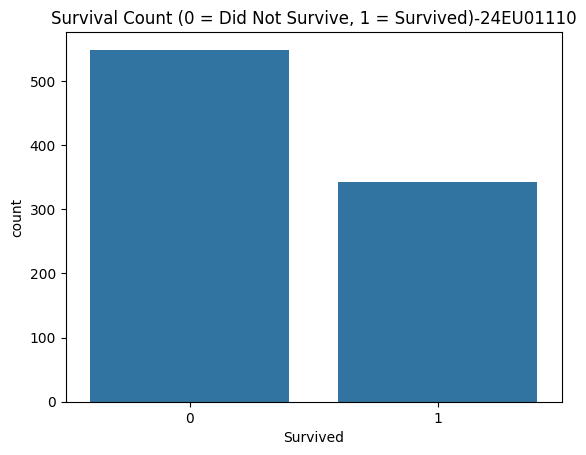

In [3]:
print(titanic_df['Survived'].value_counts())
sns.countplot(x='Survived', data=titanic_df)
plt.title("Survival Count (0 = Did Not Survive, 1 = Survived)-24EU01110")
plt.show()

In [4]:
titanic_clean = titanic_df.copy()


titanic_clean['Age'] = titanic_clean['Age'].fillna(titanic_clean['Age'].median())


titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode()[0])


titanic_clean.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'], inplace=True)


titanic_clean['FamilySize'] = titanic_clean['SibSp'] + titanic_clean['Parch'] + 1


titanic_clean['Sex'] = titanic_clean['Sex'].map({'male': 0, 'female': 1})
titanic_clean['Embarked'] = titanic_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Missing values after cleaning:")
print(titanic_clean.isnull().sum())
titanic_clean.head()

Missing values after cleaning:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,0,22.0,1,0,7.2500,0,2
1,1,1,1,38.0,1,0,71.2833,1,2
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,2
4,0,3,0,35.0,0,0,8.0500,0,1


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize']

X_titanic = titanic_clean[feature_cols]
y_titanic = titanic_clean['Survived']

scaler_titanic = StandardScaler()
X_titanic_scaled = scaler_titanic.fit_transform(X_titanic)


X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_scaled, y_titanic, test_size=0.20, stratify=y_titanic, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (712, 8)
Test set shape: (179, 8)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Test Accuracy: 80.45%


In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

lda_preds = lda_model.predict(X_test)
lda_accuracy = accuracy_score(y_test, lda_preds)

print(f"LDA Test Accuracy: {lda_accuracy * 100:.2f}%")

LDA Test Accuracy: 81.01%


In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_preds = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_preds)

print(f"k-NN Test Accuracy: {knn_accuracy * 100:.2f}%")

k-NN Test Accuracy: 81.56%


In [9]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_preds)

print(f"Gaussian Naive Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")

Gaussian Naive Bayes Test Accuracy: 78.21%


In [10]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_preds)

print(f"SVM (RBF Kernel) Test Accuracy: {svm_accuracy * 100:.2f}%")

SVM (RBF Kernel) Test Accuracy: 81.01%


In [11]:
comparison_df = pd.DataFrame({
    'Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)',
        'Gaussian Naive Bayes',
        'Support Vector Machine (SVM)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100,
        nb_accuracy * 100,
        svm_accuracy * 100
    ]
}).sort_values(by='Test Accuracy (%)', ascending=False).reset_index(drop=True)

print("--- Performance Comparison on Titanic Dataset ---")
print(comparison_df.to_string(index=False))

--- Performance Comparison on Titanic Dataset ---
                        Classifier  Test Accuracy (%)
        k-Nearest Neighbors (k-NN)          81.564246
      Support Vector Machine (SVM)          81.005587
Linear Discriminant Analysis (LDA)          81.005587
               Logistic Regression          80.446927
              Gaussian Naive Bayes          78.212291


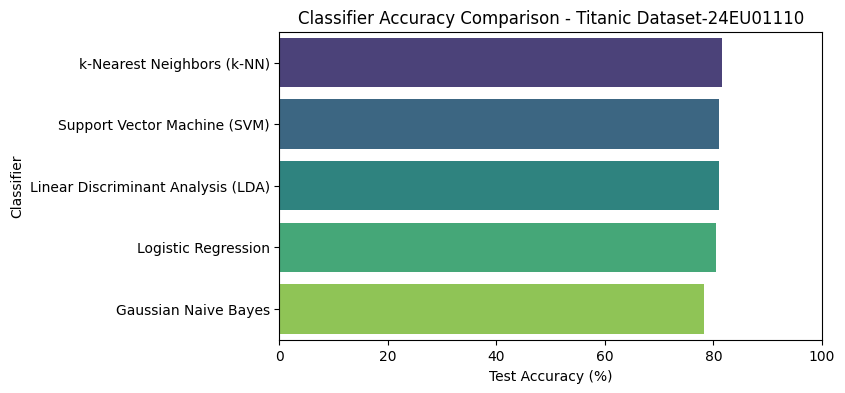

In [12]:
plt.figure(figsize=(7, 4))
sns.barplot(x='Test Accuracy (%)', y='Classifier', data=comparison_df, palette='viridis')
plt.title("Classifier Accuracy Comparison - Titanic Dataset-24EU01110")
plt.xlim(0, 100)
plt.show()

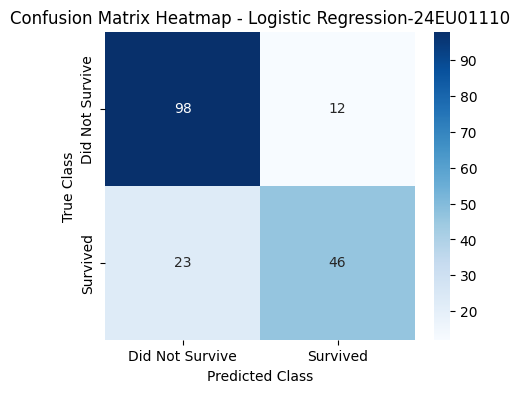

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived']
)

plt.title("Confusion Matrix Heatmap - Logistic Regression-24EU01110")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [14]:
from sklearn.metrics import classification_report

report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Did Not Survive', 'Survived']
)

print("--- Logistic Regression Classification Report ---")
print(report_output)

--- Logistic Regression Classification Report ---
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



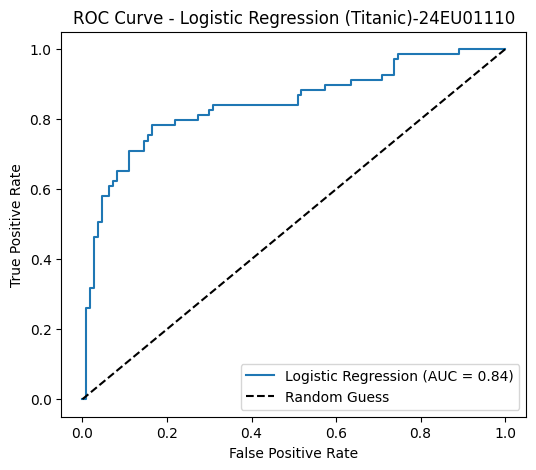

In [15]:
from sklearn.metrics import roc_curve, auc


y_score = lr_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Titanic)-24EU01110")
plt.legend(loc="lower right")
plt.show()

In [16]:
from sklearn.model_selection import cross_val_score

cv_model = LogisticRegression(random_state=42)

cv_scores = cross_val_score(
    cv_model,
    X_titanic_scaled,
    y_titanic,
    cv=5,
    scoring='accuracy'
)

print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))

5-Fold Cross-Validation Accuracy:
Fold 1: 0.7933
Fold 2: 0.7921
Fold 3: 0.7809
Fold 4: 0.7697
Fold 5: 0.8202

Mean Accuracy: 79.12%
Standard Deviation: 1.68%
